# ARTI 404 — Image Processing
## Lab 5: Spatial Filtering — Smoothing and Sharpening

**Student Name / ID:** Hassan (2240002973)  
**Course:** ARTI 404 — Image Processing  
**Session:** Lab 5 (Spatial Filtering)


## 1. Setup and Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("OpenCV version :", cv2.__version__)
print("NumPy version  :", np.__version__)


OpenCV version : 5.0.0
NumPy version  : 2.5.1


---
## Procedural Steps (Tasks)

### Task #1: Unsharp Masking
Unsharp masking sharpens an image by subtracting a blurred version of the image from the original, creating a mask that enhances high-frequency edge details.
$$\text{Sharpened} = \text{Original} + \text{amount} \times (\text{Original} - \text{Blurred})$$


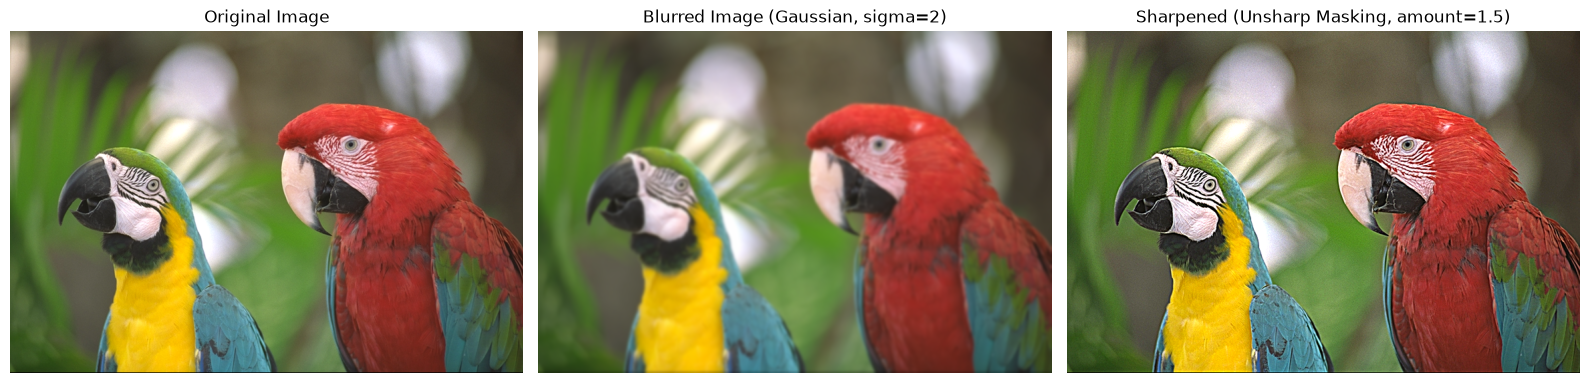

In [2]:
# Read the image
image_path = 'images/Parrot.png' if os.path.exists('images/Parrot.png') else '../images/Parrot.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

# Gaussian sigma
sigma = 2
# parameter
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image", fontsize=12)
ax[0].axis("off")

ax[1].imshow(blurred)
ax[1].set_title("Blurred Image (Gaussian, sigma=2)", fontsize=12)
ax[1].axis("off")

ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking, amount=1.5)", fontsize=12)
ax[2].axis("off")

plt.tight_layout()
plt.show()


---
## Assessment Tasks

### Assessment Task #1: Box Filter (7x7 Smoothing)
Convolve an image with a $7 \times 7$ box filter and output the original and smoothed image side by side.


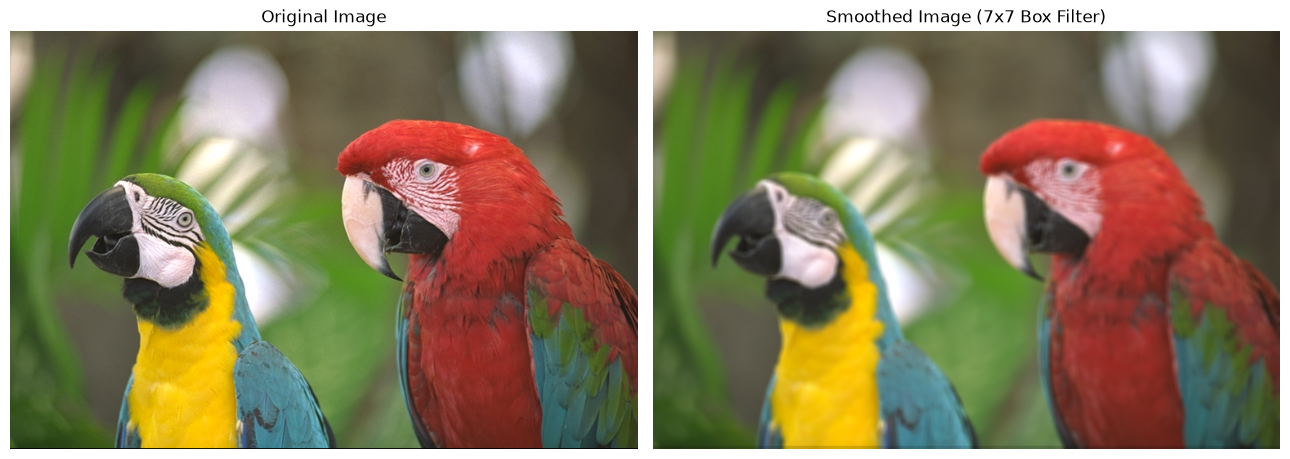

In [3]:
# Apply 7x7 Box Filter (averaging filter)
box_smoothed = cv2.blur(image, (7, 7))

# Plot Original and Box-Smoothed image side by side
fig, ax = plt.subplots(1, 2, figsize=(13, 6))

ax[0].imshow(image)
ax[0].set_title("Original Image", fontsize=12)
ax[0].axis("off")

ax[1].imshow(box_smoothed)
ax[1].set_title("Smoothed Image (7x7 Box Filter)", fontsize=12)
ax[1].axis("off")

plt.tight_layout()
plt.show()


### Assessment Task #2: Gaussian Smoothing with Different Kernel Sizes
Apply a $5 \times 5$ Gaussian filter, then a $21 \times 21$ Gaussian filter, and display the three images side by side.


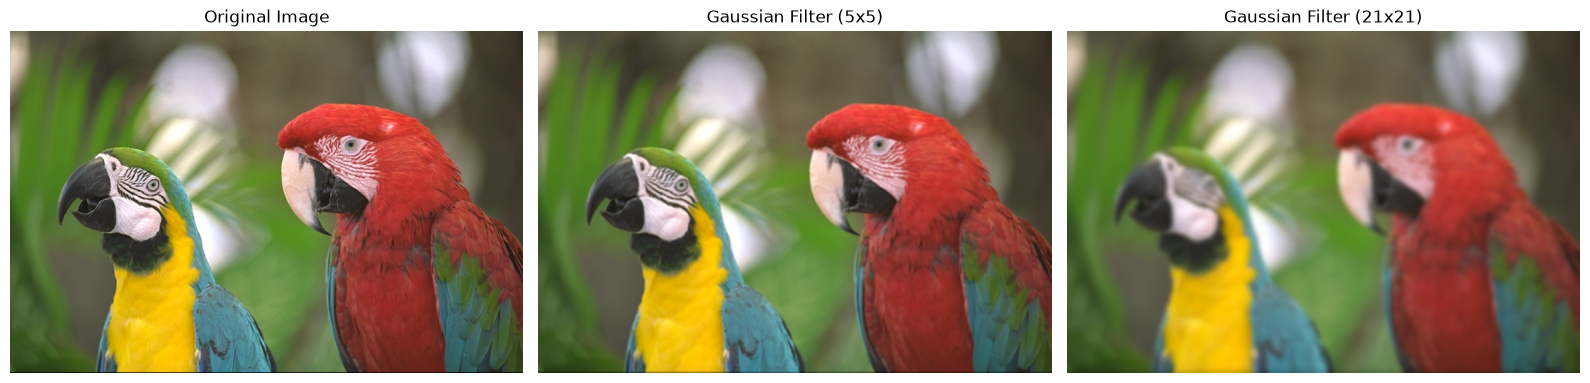

In [4]:
# Apply 5x5 Gaussian Filter
gauss_5x5 = cv2.GaussianBlur(image, (5, 5), sigmaX=0)

# Apply 21x21 Gaussian Filter
gauss_21x21 = cv2.GaussianBlur(image, (21, 21), sigmaX=0)

# Plot Original, 5x5 Gaussian, and 21x21 Gaussian side by side
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].imshow(image)
ax[0].set_title("Original Image", fontsize=12)
ax[0].axis("off")

ax[1].imshow(gauss_5x5)
ax[1].set_title("Gaussian Filter (5x5)", fontsize=12)
ax[1].axis("off")

ax[2].imshow(gauss_21x21)
ax[2].set_title("Gaussian Filter (21x21)", fontsize=12)
ax[2].axis("off")

plt.tight_layout()
plt.show()


### Assessment Task #3: Laplacian Filter Sharpening
Sharpen an image using a $3 \times 3$ Laplacian filter following these steps:
1. Read the image
2. Convert image to float32
3. Use the `cv2.Laplacian()` function
4. Sharpen the image using: `np.clip(image_float - laplacian, 0, 1)`
5. Plot the original image, Laplacian filtered image, and the sharpened image.


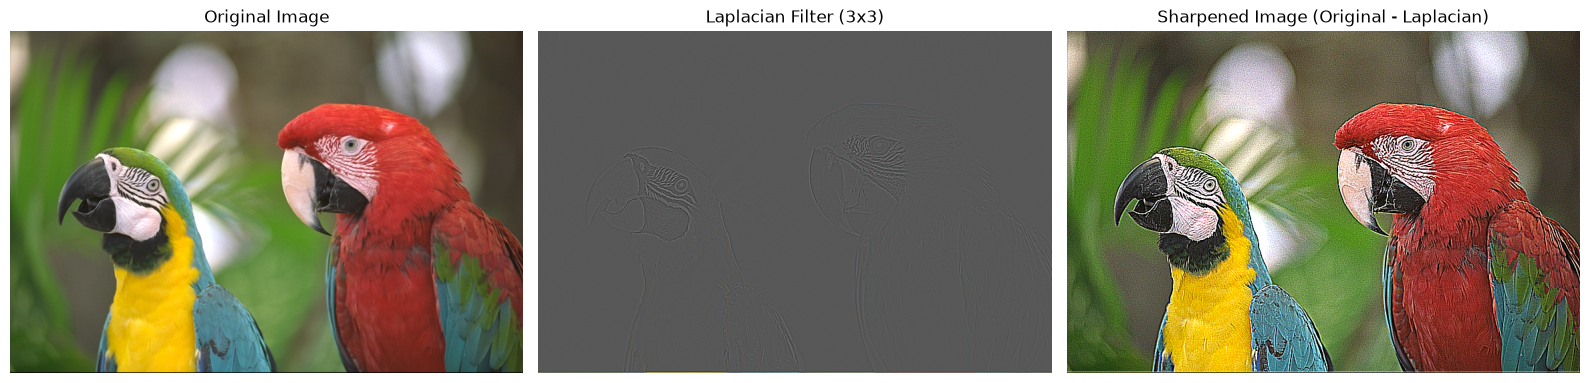

In [5]:
# Step 1: Read the image (using Parrot image converted to RGB)
image_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

# Step 2: Convert image to float32 normalized in [0, 1]
img_float = image_rgb.astype(np.float32) / 255.0

# Step 3: Apply 3x3 Laplacian filter
laplacian = cv2.Laplacian(img_float, cv2.CV_32F, ksize=3)

# Step 4: Sharpen the image using: np.clip(image_float - laplacian, 0, 1)
sharpened_lap = np.clip(img_float - laplacian, 0.0, 1.0)

# Normalize Laplacian for visualization (scale to [0, 1])
laplacian_vis = np.clip((laplacian - laplacian.min()) / (laplacian.max() - laplacian.min() + 1e-7), 0.0, 1.0)

# Step 5: Plot original, Laplacian filtered, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].imshow(img_float)
ax[0].set_title("Original Image", fontsize=12)
ax[0].axis("off")

ax[1].imshow(laplacian_vis)
ax[1].set_title("Laplacian Filter (3x3)", fontsize=12)
ax[1].axis("off")

ax[2].imshow(sharpened_lap)
ax[2].set_title("Sharpened Image (Original - Laplacian)", fontsize=12)
ax[2].axis("off")

plt.tight_layout()
plt.show()
